# About Project

**Judul Proyek:**

Early Detection of Heart Disease Using Machine Learning
Latar Belakang
Penyakit jantung merupakan salah satu penyebab kematian utama di dunia. Deteksi dini sangat penting untuk mencegah dampak yang lebih serius. Namun, diagnosis dini seringkali sulit dilakukan karena gejala yang tidak selalu jelas pada tahap awal. Machine learning menawarkan pendekatan berbasis data yang dapat membantu meningkatkan akurasi diagnosis dini dengan menganalisis berbagai faktor risiko yang berkontribusi terhadap penyakit jantung.

**Tujuan Proyek**

Membangun model machine learning yang dapat memprediksi risiko penyakit jantung pada pasien berdasarkan data kesehatan dan faktor risiko. Tujuan utama proyek ini adalah mengidentifikasi pasien dengan risiko tinggi pada tahap awal sehingga intervensi medis dapat dilakukan lebih cepat dan efektif.

# Dataset Information


**About Datasets**

Dataset yang digunakan adalah data Heart Disease yang diunduh dari UCI ML: https://archive.ics.uci.edu/dataset/45/heart+disease

Dataset yang digunakan ini berasal dari tahun 1988 dan terdiri dari empat database: Cleveland, Hungaria, Swiss, dan Long Beach V. Bidang "target" mengacu pada adanya penyakit jantung pada pasien. Ini adalah bilangan bulat bernilai 0 = tidak ada penyakit dan 1 = penyakit.

Dataset heart disease terdiri dari 1025 baris data dan 13 atribut + 1 target. Dataset ini memiliki 14 kolom yaitu:

1. age: variabel ini merepresentasikan usia pasien yang diukur dalam tahun.
2. sex: variabel ini merepresentasikan jenis kelamin pasien dengan nilai 1 untuk laki-laki dan nilai 0 untuk perempuan.
3. cp (Chest pain type): variabel ini merepresentasikan jenis nyeri dada yang dirasakan oleh pasien dengan 4 nilai kategori yang mungkin: nilai 1 mengindikasikan nyeri dada tipe angina, nilai 2 mengindikasikan nyeri dada tipe nyeri tidak stabil, nilai 3 mengindikasikan nyeri dada tipe nyeri tidak stabil yang parah, dan nilai 4 mengindikasikan nyeri dada yang tidak terkait dengan masalah jantung.
4. trestbps (Resting blood pressure): variabel ini merepresentasikan tekanan darah pasien pada saat istirahat, diukur dalam mmHg (milimeter air raksa (merkuri)).
5. chol (Serum cholestoral): variabel ini merepresentasikan kadar kolesterol serum dalam darah pasien, diukur dalam mg/dl (miligram per desiliter).
6. fbs (Fasting blood sugar): variabel ini merepresentasikan kadar gula darah pasien saat puasa (belum makan) dengan nilai 1 jika kadar gula darah > 120 mg/dl dan nilai 0 jika tidak.
7. restecg (Resting electrocardiographic results): variabel ini merepresentasikan hasil elektrokardiogram pasien saat istirahat dengan 3 nilai kategori yang mungkin: nilai 0 mengindikasikan hasil normal, nilai 1 mengindikasikan adanya kelainan gelombang ST-T, dan nilai 2 mengindikasikan hipertrofi ventrikel kiri.
8. thalach (Maximum heart rate achieved): variabel ini merepresentasikan detak jantung maksimum yang dicapai oleh pasien selama tes olahraga, diukur dalam bpm (denyut per menit).
9. exang (Exercise induced angina): variabel ini merepresentasikan apakah pasien mengalami angina (nyeri dada) yang dipicu oleh aktivitas olahraga, dengan nilai 1 jika ya dan nilai 0 jika tidak.
10. oldpeak: variabel ini merepresentasikan seberapa banyak ST segmen menurun atau depresi saat melakukan aktivitas fisik dibandingkan saat istirahat.
11. slope: variabel ini merepresentasikan kemiringan segmen ST pada elektrokardiogram (EKG) selama latihan fisik maksimal dengan 3 nilai kategori.
12. ca (Number of major vessels): variabel ini merepresentasikan jumlah pembuluh darah utama (0-3) yang terlihat pada pemeriksaan flourosopi.
13. thal: variabel ini merepresentasikan hasil tes thalium scan dengan 3 nilai kategori yang mungkin:
 - thal 1: menunjukkan kondisi normal.
 - thal 2: menunjukkan adanya defek tetap pada thalassemia.
 - thal 3: menunjukkan adanya defek yang dapat dipulihkan pada thalassemia.
14. target: 0 = tidak ada penyakit dan 1 = penyakit.

# Data Preprocessing


**Library Preparation**


In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import math
import random
import seaborn as sns
from scipy.stats import pearsonr, jarque_bera #Fungsi statistik
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# Modelling Librararies
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

**Dataset Loading and Show 5 first row**




In [ ]:
# Dataset Loading
path = "/content/heart_disease.csv"
column_names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
data = pd.read_csv(path, names=column_names, skiprows=[0])

In [ ]:
# Menampilkan lima baris teratas
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Menampilkan lima baris terbawah
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
# Melihat jumlah dataset (jumlah baris dan kolom)
data.shape

(1025, 14)

In [ ]:
# Melihat columns apa saja yang ada dalam dataset
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
# Melihat persebaran data
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
# Melihat uniqueness data
data.nunique()

,0
age,41
sex,2
cp,4
trestbps,49
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [ ]:
# Melihat informasi dari dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


##**Data Quality**

In [ ]:
# Melakukan handling kolom menjadi kategorikal
lst=[ 'sex', 'cp', 'trestbps', 'fbs', 'restecg','exang',  'slope','ca','thal', 'target']
data[lst] = data[lst].astype(object)

# Melihat perubahan
data.dtypes

,0
age,int64
sex,object
cp,object
trestbps,object
chol,int64
fbs,object
restecg,object
thalach,int64
exang,object
oldpeak,float64


In [ ]:
# Pelabelan data categorical
data['sex'] = data['sex'].replace({1: 'Male',
                                   0: 'Female'})
data['cp'] = data['cp'].replace({0: 'typical angina',
                                 1: 'atypical angina',
                                 2: 'non-anginal pain',
                                 3: 'asymtomatic'})
data['fbs'] = data['fbs'].replace({0: 'No',
                                   1: 'Yes'})
data['restecg'] = data['restecg'].replace({0: 'probable or definite left ventricular hypertrophy',
                                           1:'normal',
                                           2: 'ST-T Wave abnormal'})
data['exang'] = data['exang'].replace({0: 'No',
                                       1: 'Yes'})
data['slope'] = data['slope'].replace({0: 'downsloping',
                                       1: 'flat',
                                       2: 'upsloping'})
data['thal'] = data['thal'].replace({1: 'normal',
                                     2: 'fixed defect',
                                     3: 'reversable defect'})
data['ca'] = data['ca'].replace({0: 'Number of major vessels: 0',
                                 1: 'Number of major vessels: 1',
                                 2: 'Number of major vessels: 2',
                                 3: 'Number of major vessels: 3'})
data['target'] = data['target'].replace({0: 'No disease',
                                         1: 'Disease'})

In [ ]:
# Pisahkan numerical dan categorical
numerical_col = data.select_dtypes(exclude='object')
categorical_col = data.select_dtypes(exclude='number')

In [ ]:
# Pengecekan karakter dari data kategorikal
for i in categorical_col:
    print("Berikut ini merupakan informasi: {} dengan {}".format(i, data[i].unique()))
    print()

Berikut ini merupakan informasi: sex dengan ['Male' 'Female']

Berikut ini merupakan informasi: cp dengan ['typical angina' 'atypical angina' 'non-anginal pain' 'asymtomatic']

Berikut ini merupakan informasi: trestbps dengan [125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115 94 200 165 102 105 155 172 164 156 101]

Berikut ini merupakan informasi: fbs dengan ['No' 'Yes']

Berikut ini merupakan informasi: restecg dengan ['normal' 'probable or definite left ventricular hypertrophy'
 'ST-T Wave abnormal']

Berikut ini merupakan informasi: exang dengan ['No' 'Yes']

Berikut ini merupakan informasi: slope dengan ['upsloping' 'downsloping' 'flat']

Berikut ini merupakan informasi: ca dengan ['Number of major vessels: 2' 'Number of major vessels: 0'
 'Number of major vessels: 1' 'Number of major vessels: 3' 4]

Berikut ini merupakan informasi: thal dengan ['reversable defect' 'fixed de

In [ ]:
for i in numerical_col:
    print("Berikut ini merupakan informasi: {} dengan {}".format(i, data[i].unique()))
    print()

Berikut ini merupakan informasi: age dengan [52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]

Berikut ini merupakan informasi: chol dengan [212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 264 276 322 214 273 253 176 284 305 168
 407 290 277 262 195 166 178 141]

Berikut ini merupakan informasi: thalach dengan [168 155 125 161 106 122 140 145 144 116 136 192 156 142 109 162 165 148
 172 173 146 179 152 117 115 112 163 147 182

In [ ]:
# Melihat jumlah nilai unik dari kolom 'ca'
data['ca'].value_counts()

,count
ca,
Number of major vessels: 0,578
Number of major vessels: 1,226
Number of major vessels: 2,134
Number of major vessels: 3,69
4,18


In [ ]:
# Menemukan baris dengan kolom 'ca' bernilai '4'
data[data['ca']==4]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
52,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
83,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
128,52,Male,non-anginal pain,138,223,No,normal,169,No,0.0,upsloping,4,fixed defect,Disease
208,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
242,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
290,52,Male,non-anginal pain,138,223,No,normal,169,No,0.0,upsloping,4,fixed defect,Disease
340,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
348,43,Male,typical angina,132,247,Yes,probable or definite left ventricular hypertrophy,143,Yes,0.1,flat,4,reversable defect,No disease
417,52,Male,non-anginal pain,138,223,No,normal,169,No,0.0,upsloping,4,fixed defect,Disease
428,43,Male,typical angina,132,247,Yes,probable or definite left ventricular hypertrophy,143,Yes,0.1,flat,4,reversable defect,No disease


In [ ]:
# Ganti kolom 'ca' yang bernilai '4' menjadi NaN
data.loc[data['ca']==4, 'ca'] = np.nan

In [ ]:
# Cek kembali apakah masih ada data kolom 'ca' yang bernilai '4'
data['ca'].value_counts()

,count
ca,
Number of major vessels: 0,578
Number of major vessels: 1,226
Number of major vessels: 2,134
Number of major vessels: 3,69


In [ ]:
# Melihat jumlah nilai unik dari kolom 'thal'
data['thal'].value_counts()

,count
thal,
fixed defect,544
reversable defect,410
normal,64
0,7


In [ ]:
# Menemukan baris dengan kolom 'thal' bernilai '0'
data[data['thal']==0]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
14,52,Male,typical angina,128,204,Yes,normal,156,Yes,1.0,flat,Number of major vessels: 0,0,No disease
319,53,Female,non-anginal pain,128,216,No,probable or definite left ventricular hypertrophy,115,No,0.0,upsloping,Number of major vessels: 0,0,Disease
329,53,Female,non-anginal pain,128,216,No,probable or definite left ventricular hypertrophy,115,No,0.0,upsloping,Number of major vessels: 0,0,Disease
359,53,Female,non-anginal pain,128,216,No,probable or definite left ventricular hypertrophy,115,No,0.0,upsloping,Number of major vessels: 0,0,Disease
686,52,Male,typical angina,128,204,Yes,normal,156,Yes,1.0,flat,Number of major vessels: 0,0,No disease
734,52,Male,typical angina,128,204,Yes,normal,156,Yes,1.0,flat,Number of major vessels: 0,0,No disease
893,52,Male,typical angina,128,204,Yes,normal,156,Yes,1.0,flat,Number of major vessels: 0,0,No disease


In [ ]:
# Ganti kolom 'thal' yang bernilai '0' menjadi NaN
data.loc[data['thal']==0, 'thal'] = np.nan

In [ ]:
# Cek kembali apakah masih ada data kolom 'thal' yang bernilai '0'
data['thal'].value_counts()

,count
thal,
fixed defect,544
reversable defect,410
normal,64


In [ ]:
# Check missing values
print("Hasil missing value:\n", data.isnull().sum())

Hasil missing value:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca          18
thal         7
target       0
dtype: int64


In [ ]:
# Reason : Modus dipilih untuk mengisi data tersebut,karena data yang digunakan adalah kategorikal
modus_ca = data['ca'].mode()[0]
# Reason : [0],mengambil nilai modus yang muncul pertama
# Reason : [0],juga berfungsi mengembalikan data sesuai dengan defaultnya,jika tidak menggunakan ini maka berubah menjadi time series
data['ca'] = data['ca'].fillna(modus_ca)


# Fillna pada kolom 'thal' dengan modus
modus_thal = data['thal'].mode()[0]
data['thal'] = data['thal'].fillna(modus_thal)

In [ ]:
# Check missing values kembali
print("Hasil missing value:\n", data.isnull().sum())

Hasil missing value:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


**Duplicated Data**

In [ ]:
# Memeriksa duplikat data
data.duplicated().sum()

723

In [ ]:
# Menampilkan baris data duplicate
data[data.duplicated()].sort_values(by='age')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
118,29,Male,atypical angina,130,204,No,probable or definite left ventricular hypertrophy,202,No,0.0,upsloping,Number of major vessels: 0,fixed defect,Disease
64,29,Male,atypical angina,130,204,No,probable or definite left ventricular hypertrophy,202,No,0.0,upsloping,Number of major vessels: 0,fixed defect,Disease
668,29,Male,atypical angina,130,204,No,probable or definite left ventricular hypertrophy,202,No,0.0,upsloping,Number of major vessels: 0,fixed defect,Disease
15,34,Female,atypical angina,118,210,No,normal,192,No,0.7,upsloping,Number of major vessels: 0,fixed defect,Disease
779,34,Female,atypical angina,118,210,No,normal,192,No,0.7,upsloping,Number of major vessels: 0,fixed defect,Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,74,Female,atypical angina,120,269,No,probable or definite left ventricular hypertrophy,121,Yes,0.2,upsloping,Number of major vessels: 1,fixed defect,Disease
535,76,Female,non-anginal pain,140,197,No,ST-T Wave abnormal,116,No,1.1,flat,Number of major vessels: 0,fixed defect,Disease
965,76,Female,non-anginal pain,140,197,No,ST-T Wave abnormal,116,No,1.1,flat,Number of major vessels: 0,fixed defect,Disease
162,77,Male,typical angina,125,304,No,probable or definite left ventricular hypertrophy,162,Yes,0.0,upsloping,Number of major vessels: 3,fixed defect,No disease


In [ ]:
# Menghapus data duplikat
data.drop_duplicates(inplace=True,keep='first') #Menghapus yang lain dan menyisakan satu data dengan pertimbangan indeks terkecil

# Memeriksa ulang duplikat data
print("The total number of duplicate data after removal is ",data.duplicated().sum())

The total number of duplicate data after removal is  0


In [ ]:
#Memeriksa duolikat data pada table
data[data.duplicated()].sort_values(by='age')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


**Outlier Data**

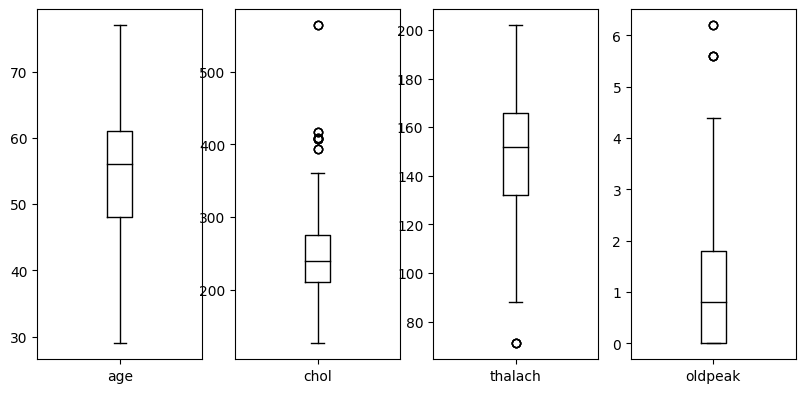

In [ ]:
#Menampilkan boxplot untuk melihat outliers data numerik
numerical_col.plot(kind = 'box', subplots = True, layout = (2,8), sharex = False, sharey = False, figsize = (20, 10), color = 'k')
plt.show()

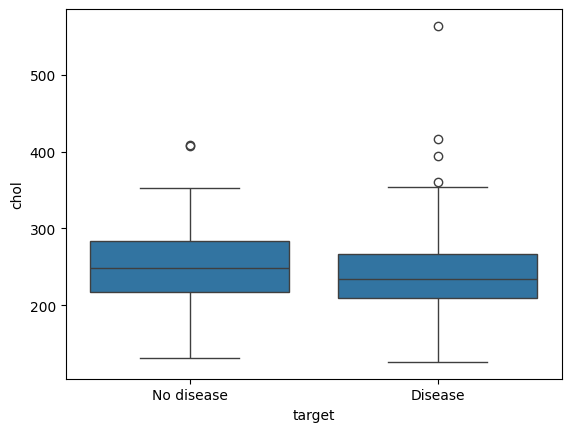

In [ ]:
# Menampilkan data berdasarkan target untuk feature chol
sns.boxplot(x='target',y='chol',data=data)
plt.show()

In [ ]:
# Mencari tahu data yang outliers dengan mendefinisikan fungsi
continous_features = ['age','trestbps','chol','thalach','oldpeak']
def outliers(data_out, drop = False):
    for each_feature in data_out.columns:
        feature_data = data_out[each_feature]
        Q1 = np.percentile(feature_data, 25.)
        Q3 = np.percentile(feature_data, 75.)
        IQR = Q3-Q1
        outlier_step = IQR * 1.5
        outliers = feature_data[~((feature_data >= Q1 - outlier_step) & (feature_data <= Q3 + outlier_step))].index.tolist()
        if not drop:
            print('For the feature {}, Num of Outliers is {}'.format(each_feature, len(outliers)))
        if drop:
            data.drop(outliers, inplace = True, errors = 'ignore')
            print('Outliers from {} feature removed'.format(each_feature))

# Menampilkan jumlah data yang oulier
outliers(data_out=data[continous_features])

For the feature age, Num of Outliers is 0
For the feature trestbps, Num of Outliers is 9
For the feature chol, Num of Outliers is 5
For the feature thalach, Num of Outliers is 1
For the feature oldpeak, Num of Outliers is 5


In [ ]:
# Menghapus outlier dengan fungsi sebelumnya
outliers(drop=True,data_out=data[continous_features])

Outliers from age feature removed
Outliers from trestbps feature removed
Outliers from chol feature removed
Outliers from thalach feature removed
Outliers from oldpeak feature removed


**Melihat informasi dari data kategorikal**


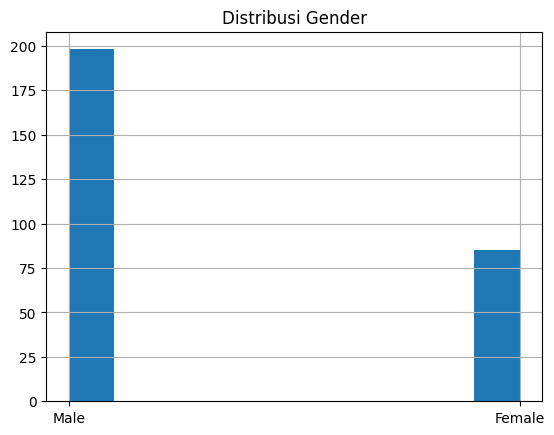

In [ ]:
# Jumlah kategori sex pada dataset
data['sex'].hist().plot(kind='bar')
plt.title('Distribusi Gender')
plt.show()

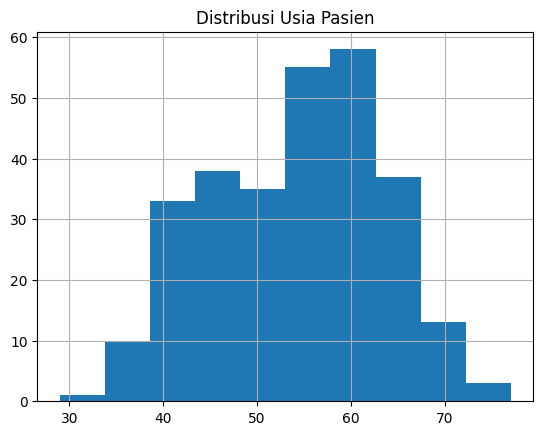

In [ ]:
# Jumlah kategori age pada dataset
data['age'].hist().plot(kind='bar')
plt.title('Distribusi Usia Pasien')
plt.show()

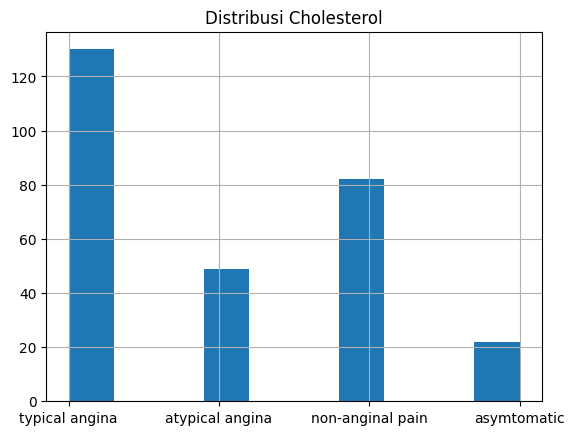

In [ ]:
# Jumlah kategori cp pada dataset
data['cp'].hist().plot(kind='bar')
plt.title('Distribusi Cholesterol')
plt.show()

**Imbalanced Data**

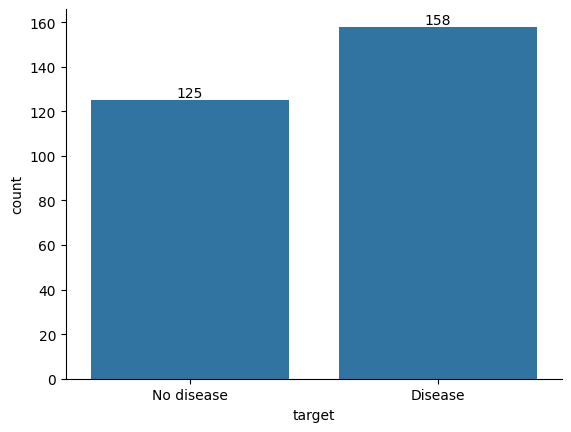

In [ ]:
# Memeriksa data imbalance
ax = sns.countplot(x='target', data=data)
for label in ax.containers:
    ax.bar_label(label)
sns.despine()
plt.show()

Data cukup seimbang (balanced), karena tidak terdapat perbedaan yang signifikan dimana terdiagnosa **disease** adalah 55.8% (158 cases), dan lain halnya untuk **no disease** adalah kurang dari 45%.

**Descrytive Statistic**

In [ ]:
# Melihat statistik deskriptif dari data
data.describe()

,age,chol,thalach,oldpeak
count,283.000000,283.000000,283.000000,283.000000
mean,54.049470,242.314488,149.961131,0.951943
std,9.128186,44.654188,22.691625,1.026400
min,29.000000,126.000000,88.000000,0.000000
25%,47.000000,210.500000,133.500000,0.000000
50%,55.000000,239.000000,153.000000,0.600000
75%,60.000000,270.500000,168.000000,1.600000
max,77.000000,360.000000,202.000000,4.000000


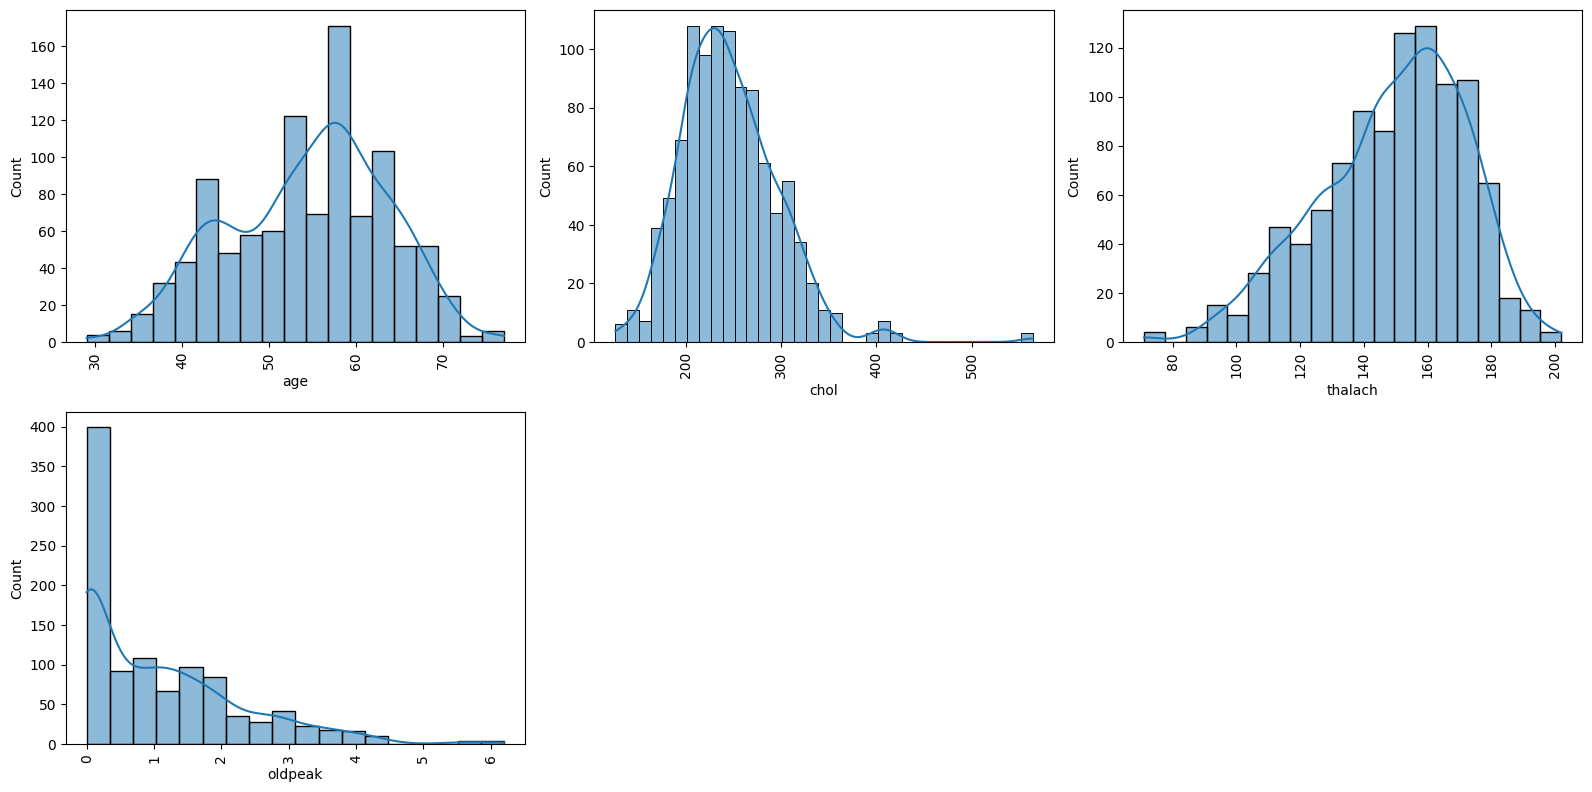

In [ ]:
# Memvisualisasikan distribusi variabel numerical
plt.figure(figsize=(16,8))
for index,column in enumerate(numerical_col):
    plt.subplot(2,3,index+1)
    sns.histplot(data=numerical_col,x=column,kde=True)
    plt.xticks(rotation = 90)
plt.tight_layout(pad = 1.0)
plt.show()

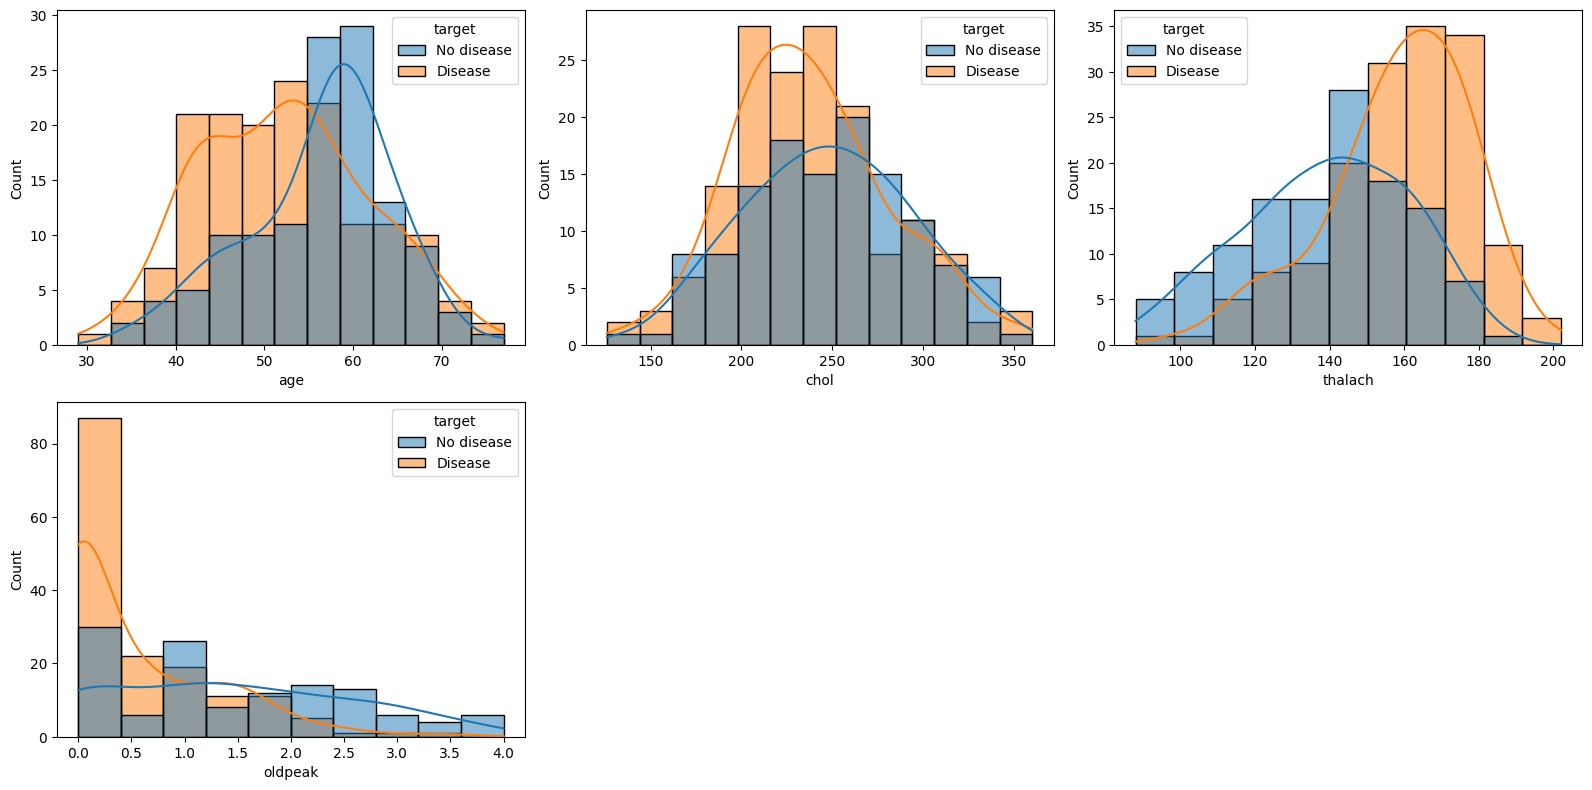

In [ ]:
plt.figure(figsize=(16,8))
for index, column in enumerate(numerical_col):
    plt.subplot(2,3, index+1 )  # Menyesuaikan jumlah subplot
    sns.histplot(data=data, x=column, kde=True, hue='target')
    #plt.xticks(rotation=90)

plt.subplots_adjust(hspace=1)  # Atur jarak antar kolom (semakin besar nilainya, semakin lebar jaraknya)
plt.tight_layout(pad=1.0)
plt.show()


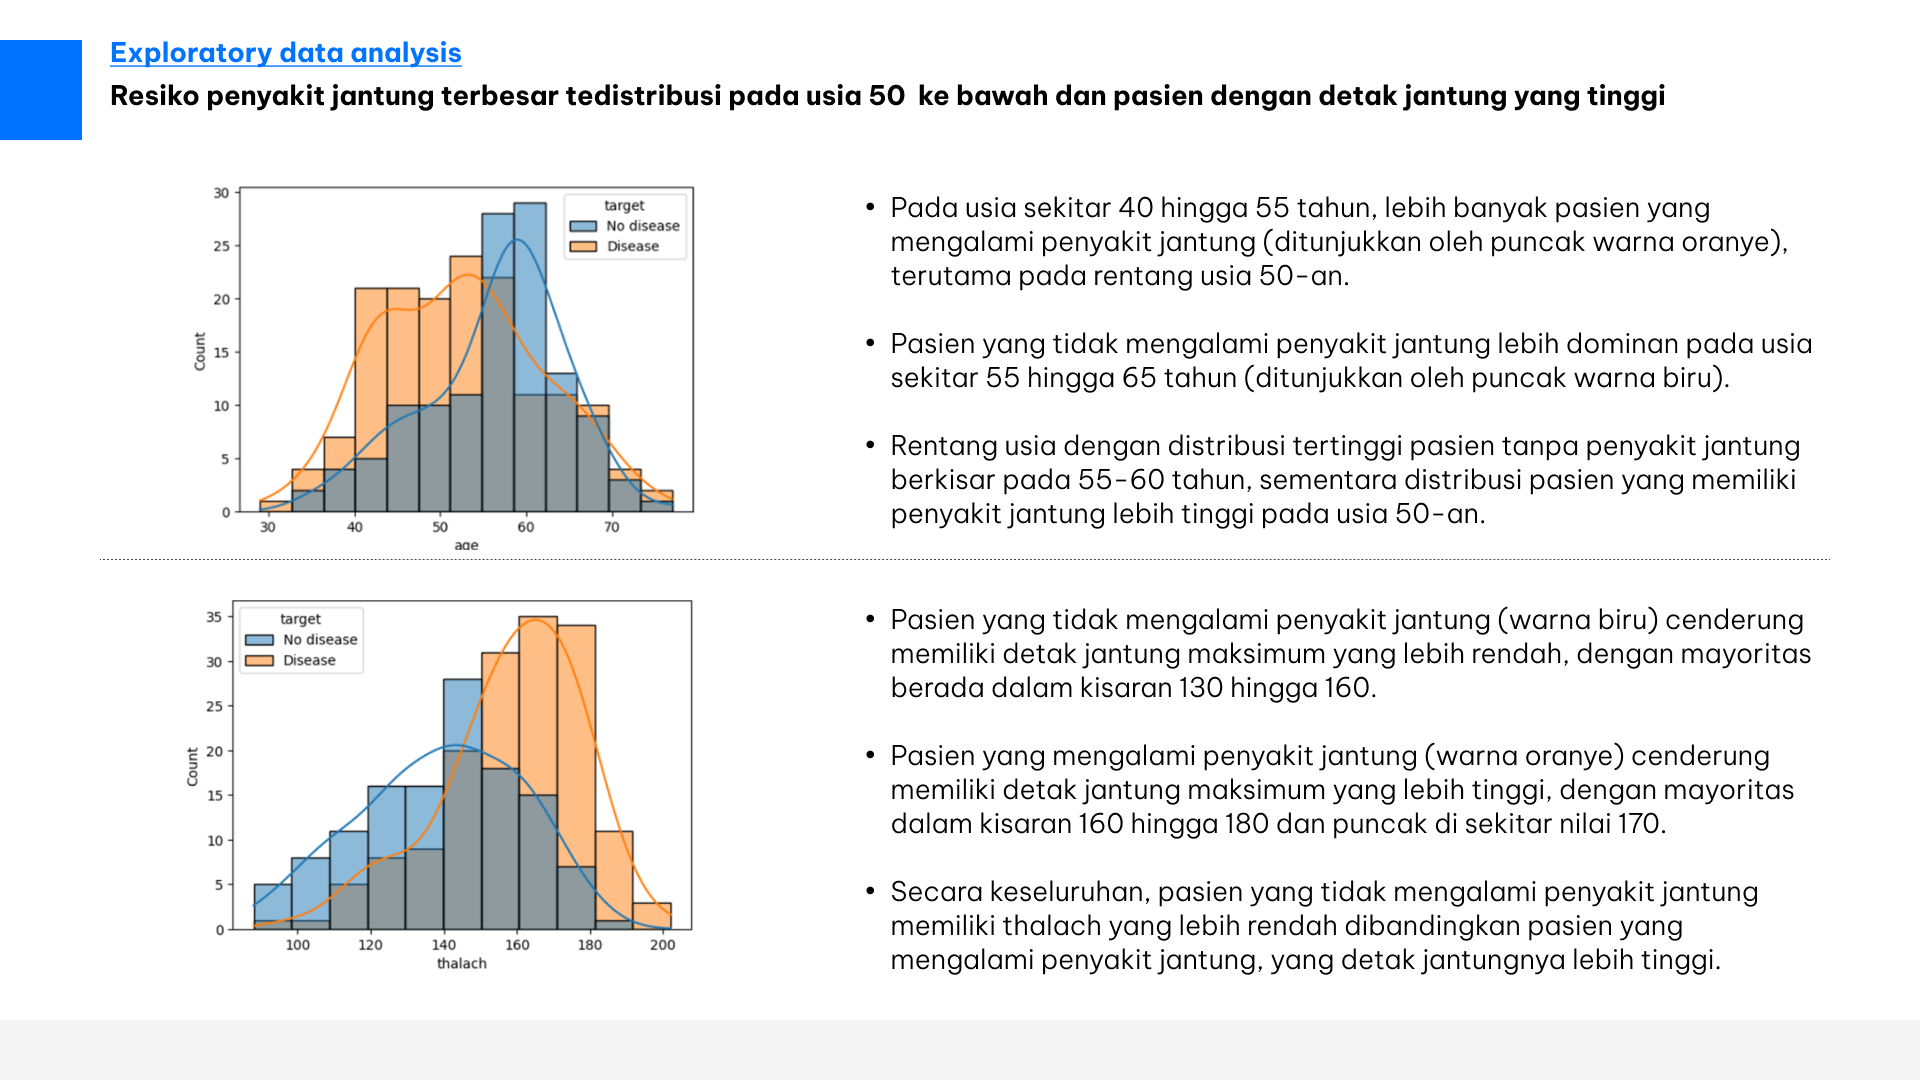

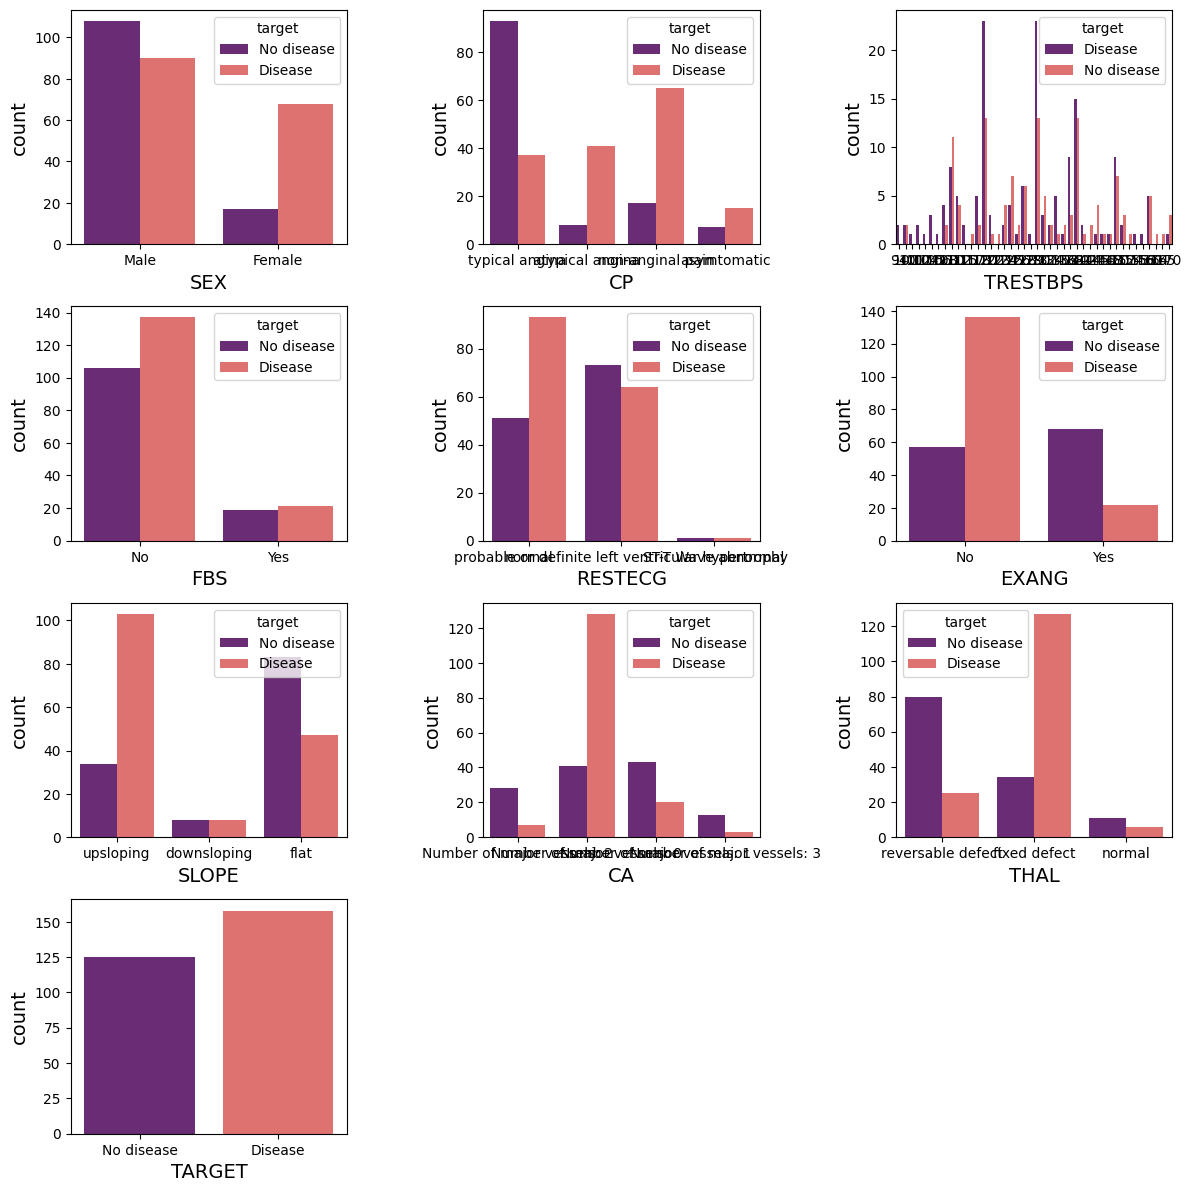

In [ ]:
# Memvisualisasikan distribusi variabel kategorikal
plt.figure(figsize=(12,12))
for index, column in enumerate(categorical_col):
    plt.subplot(4, 3, index+1)
    sns.countplot(data=data,x=column, hue='target', palette='magma')
    plt.xlabel(column.upper(),fontsize=14)
    plt.ylabel("count", fontsize=14)

plt.tight_layout(pad = 1.0)
plt.show()

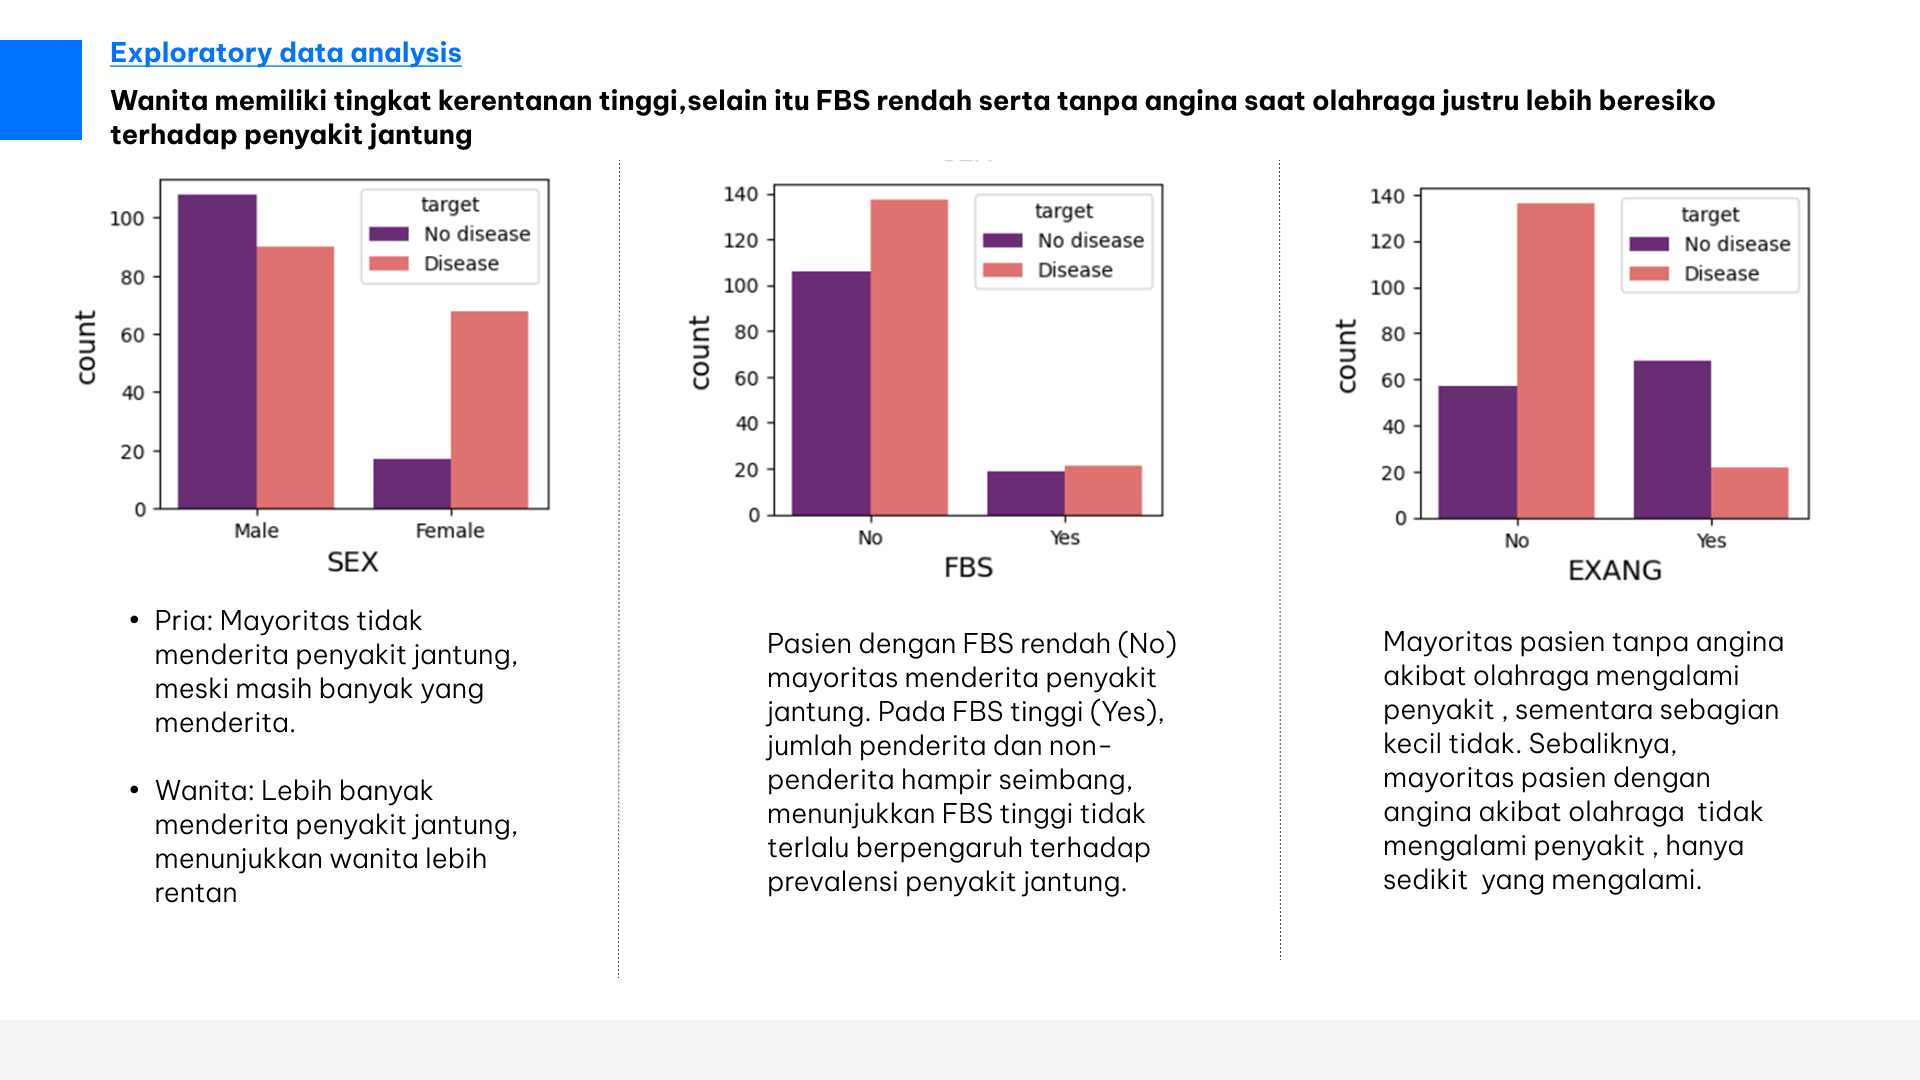

**Melihat korelasi antara feature**

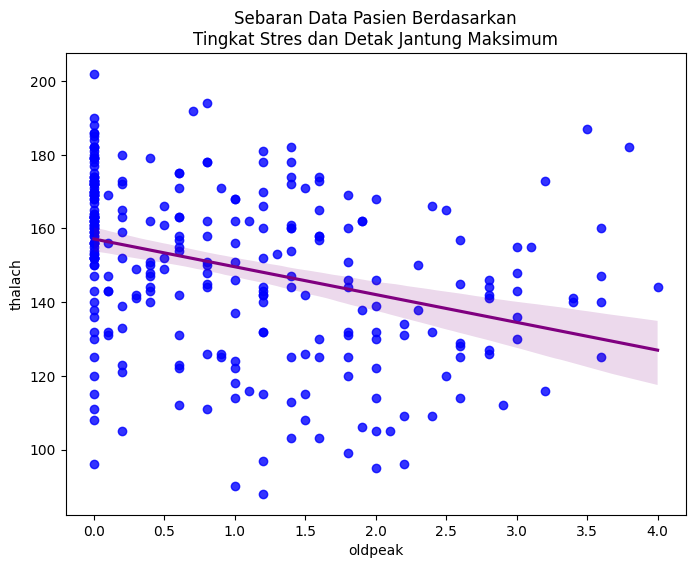

In [ ]:
# melihat korelasi tingkat depresi dan detak jantung maksimum
plt.figure(figsize = (8,6))
sns.regplot(data=data,x='oldpeak',y='thalach', scatter_kws = {'color':'blue'}, line_kws = {'color':'purple'})
plt.title('Sebaran Data Pasien Berdasarkan\nTingkat Stres dan Detak Jantung Maksimum')
plt.show()

**Convert 'trestbps' feature to numeric**

In [ ]:
import pandas as pd

# Check if the column is numeric
is_numeric_oldpeak = pd.api.types.is_numeric_dtype(data['oldpeak'])
is_numeric_trestbps = pd.api.types.is_numeric_dtype(data['trestbps'])

print(f"Is 'oldpeak' numeric? {is_numeric_oldpeak}")
print(f"Is 'trestbps' numeric? {is_numeric_trestbps}")


Is 'oldpeak' numeric? True
Is 'trestbps' numeric? False


In [ ]:
data['trestbps'].isnull().sum()

0

In [ ]:
data['trestbps'] = pd.to_numeric(data['trestbps'])

In [ ]:
# Check if the column is numeric
is_numeric_trestbps = pd.api.types.is_numeric_dtype(data['trestbps'])
print(f"Is 'trestbps' numeric? {is_numeric_trestbps}")


Is 'trestbps' numeric? True


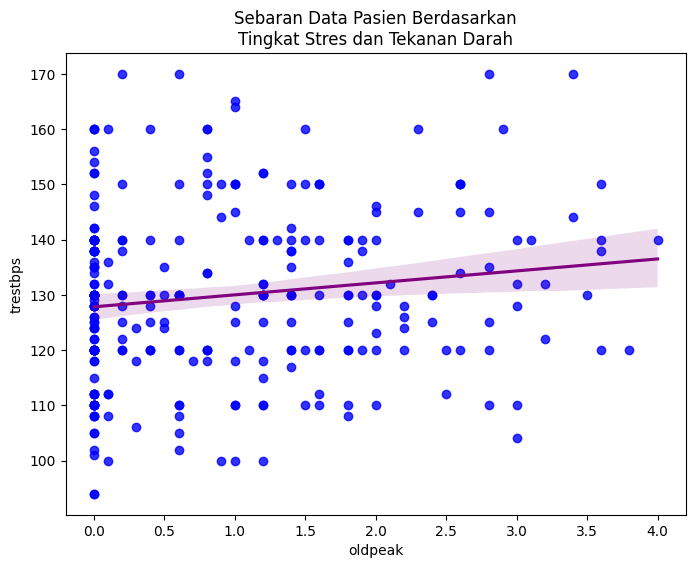

In [ ]:
# melihat korelasi tingkat depresi dan tekanan darah
plt.figure(figsize = (8,6))
sns.regplot(data = data,x='oldpeak',y='trestbps', scatter_kws = {'color':'blue'}, line_kws = {'color':'purple'})
plt.title('Sebaran Data Pasien Berdasarkan\nTingkat Stres dan Tekanan Darah')
plt.show()

In [ ]:
# Simpan data yang sudah ada label
data.to_csv('data.csv')

# Melabeli kembali datanya
df = pd.read_csv('data.csv', index_col=0)
df['sex'] = df['sex'].replace({'Male' : 1,'Female': 0})
df['cp'] = df['cp'].replace({'typical angina' : 0, 'atypical angina' : 1, 'non-anginal pain' : 2, 'asymtomatic' : 3})
df['fbs'] = df['fbs'].replace({'No' : 0, 'Yes' : 1})
df['restecg'] = df['restecg'].replace({'probable or definite left ventricular hypertrophy':0,'normal':1,'ST-T Wave abnormal':2})
df['exang'] = df['exang'].replace({'No':0,'Yes':1})
df['slope'] = df['slope'].replace({'downsloping':0, 'flat':1,'upsloping':2})
df['thal'] = df['thal'].replace({'normal':1, 'fixed defect':2,'reversable defect':3})
df['ca'] = df['ca'].replace({'Number of major vessels: 0':0, 'Number of major vessels: 1':1,'Number of major vessels: 2':2, 'Number of major vessels: 3':3})
df['target'] = df['target'].replace({'No disease':0,'Disease':1})

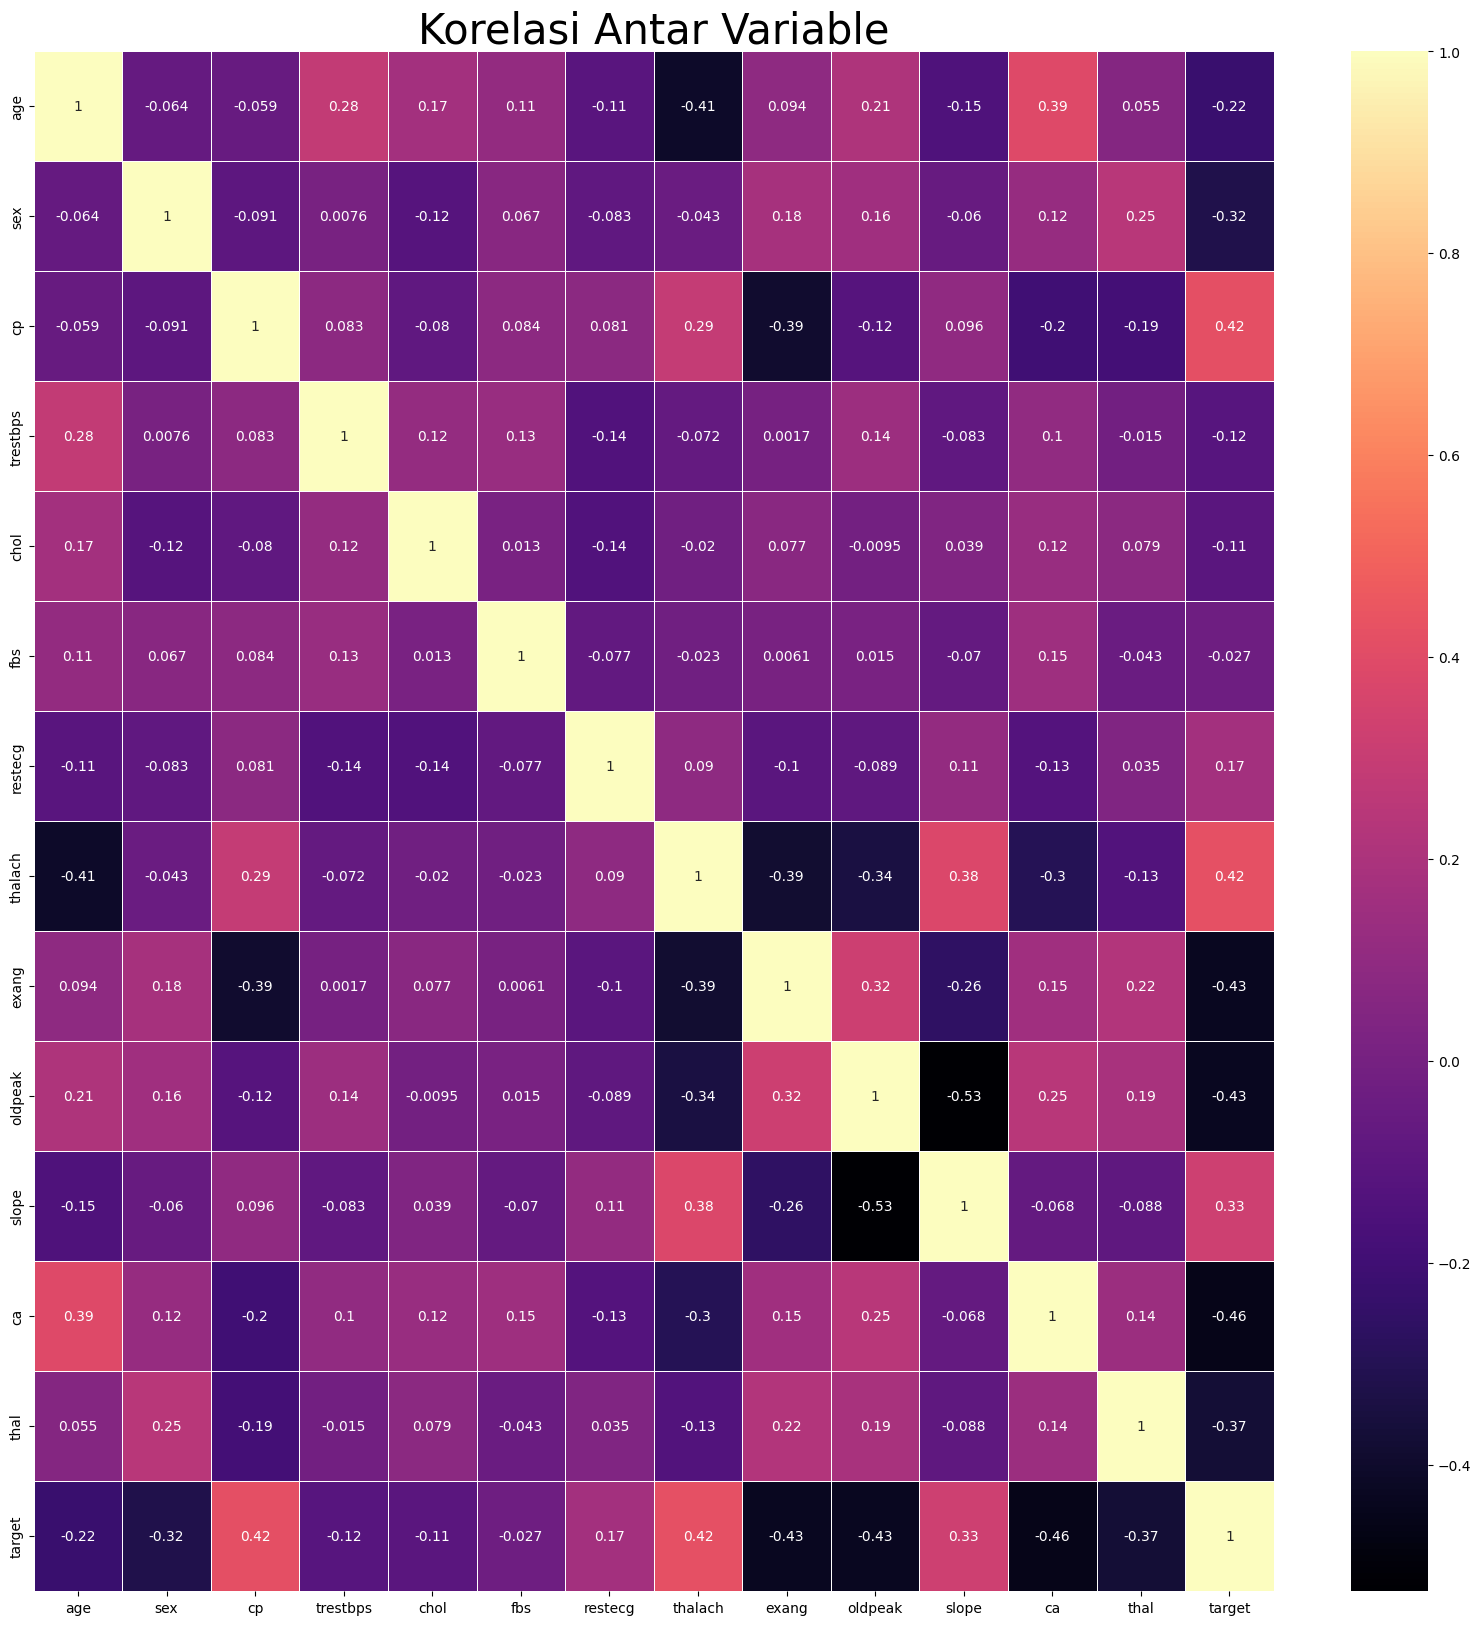

In [ ]:
'''TODO: Menampilkan grafik korelasi'''
# melihat korelasi antar variable untuk mencari feature yang penting
plt.figure(figsize=(20,20))
cor = df.corr()
sns.heatmap(cor,annot=True, linewidth=.5, cmap="magma")
plt.title('Korelasi Antar Variable', fontsize = 30)
plt.show()

In [ ]:
'''TODO: Menampilkan tabel korelasi'''
cor_matrix = df.corr()
cor_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.064118,-0.058687,0.282669,0.171015,0.106885,-0.110517,-0.411108,0.093718,0.209254,-0.149095,0.392130,0.054752,-0.222416
sex,-0.064118,1.000000,-0.091357,0.007572,-0.123863,0.066692,-0.083290,-0.042981,0.182596,0.157352,-0.060014,0.122489,0.245682,-0.318896
cp,-0.058687,-0.091357,1.000000,0.083242,-0.080369,0.084389,0.080836,0.285605,-0.388610,-0.122582,0.095881,-0.202923,-0.188487,0.416319
trestbps,0.282669,0.007572,0.083242,1.000000,0.115138,0.127221,-0.139228,-0.071600,0.001726,0.144438,-0.083024,0.101059,-0.014615,-0.115614
chol,0.171015,-0.123863,-0.080369,0.115138,1.000000,0.013066,-0.142285,-0.020128,0.076547,-0.009534,0.039352,0.124800,0.078868,-0.105627
fbs,0.106885,0.066692,0.084389,0.127221,0.013066,1.000000,-0.077417,-0.023484,0.006080,0.015070,-0.069563,0.150552,-0.042766,-0.027210
restecg,-0.110517,-0.083290,0.080836,-0.139228,-0.142285,-0.077417,1.000000,0.089556,-0.104440,-0.089255,0.111841,-0.126825,0.035452,0.171453
thalach,-0.411108,-0.042981,0.285605,-0.071600,-0.020128,-0.023484,0.089556,1.000000,-0.387726,-0.341190,0.376494,-0.296480,-0.134498,0.422559
exang,0.093718,0.182596,-0.388610,0.001726,0.076547,0.006080,-0.104440,-0.387726,1.000000,0.318620,-0.259780,0.154768,0.223241,-0.431599
oldpeak,0.209254,0.157352,-0.122582,0.144438,-0.009534,0.015070,-0.089255,-0.341190,0.318620,1.000000,-0.525142,0.245318,0.189228,-0.434108


In [ ]:
#Mengurutkan korelasi
cor_matrix['target'].sort_values()

,target
ca,-0.456989
oldpeak,-0.434108
exang,-0.431599
thal,-0.370759
sex,-0.318896
age,-0.222416
trestbps,-0.115614
chol,-0.105627
fbs,-0.027210
restecg,0.171453


Deskripsi

'cp', 'thalach', dan 'slope' berkorelasi positif cukup kuat dengan 'target'.
'oldpeak', 'exang', 'ca', 'thal', 'sex', dan 'age' berkorelasi cukup kuat dengan 'target'.

'fbs', 'chol', 'trestbps', dan 'restecg' memiliki korelasi yang lemah dengan 'target'.

**Feature yang dipilih yaitu :'cp', 'thalach', 'slope', 'oldpeak', 'exang', 'ca', 'thal', 'sex', dan 'age' untuk dianalisa lebih lanjut.**

**Melihat Korelasi Variabel ke target**

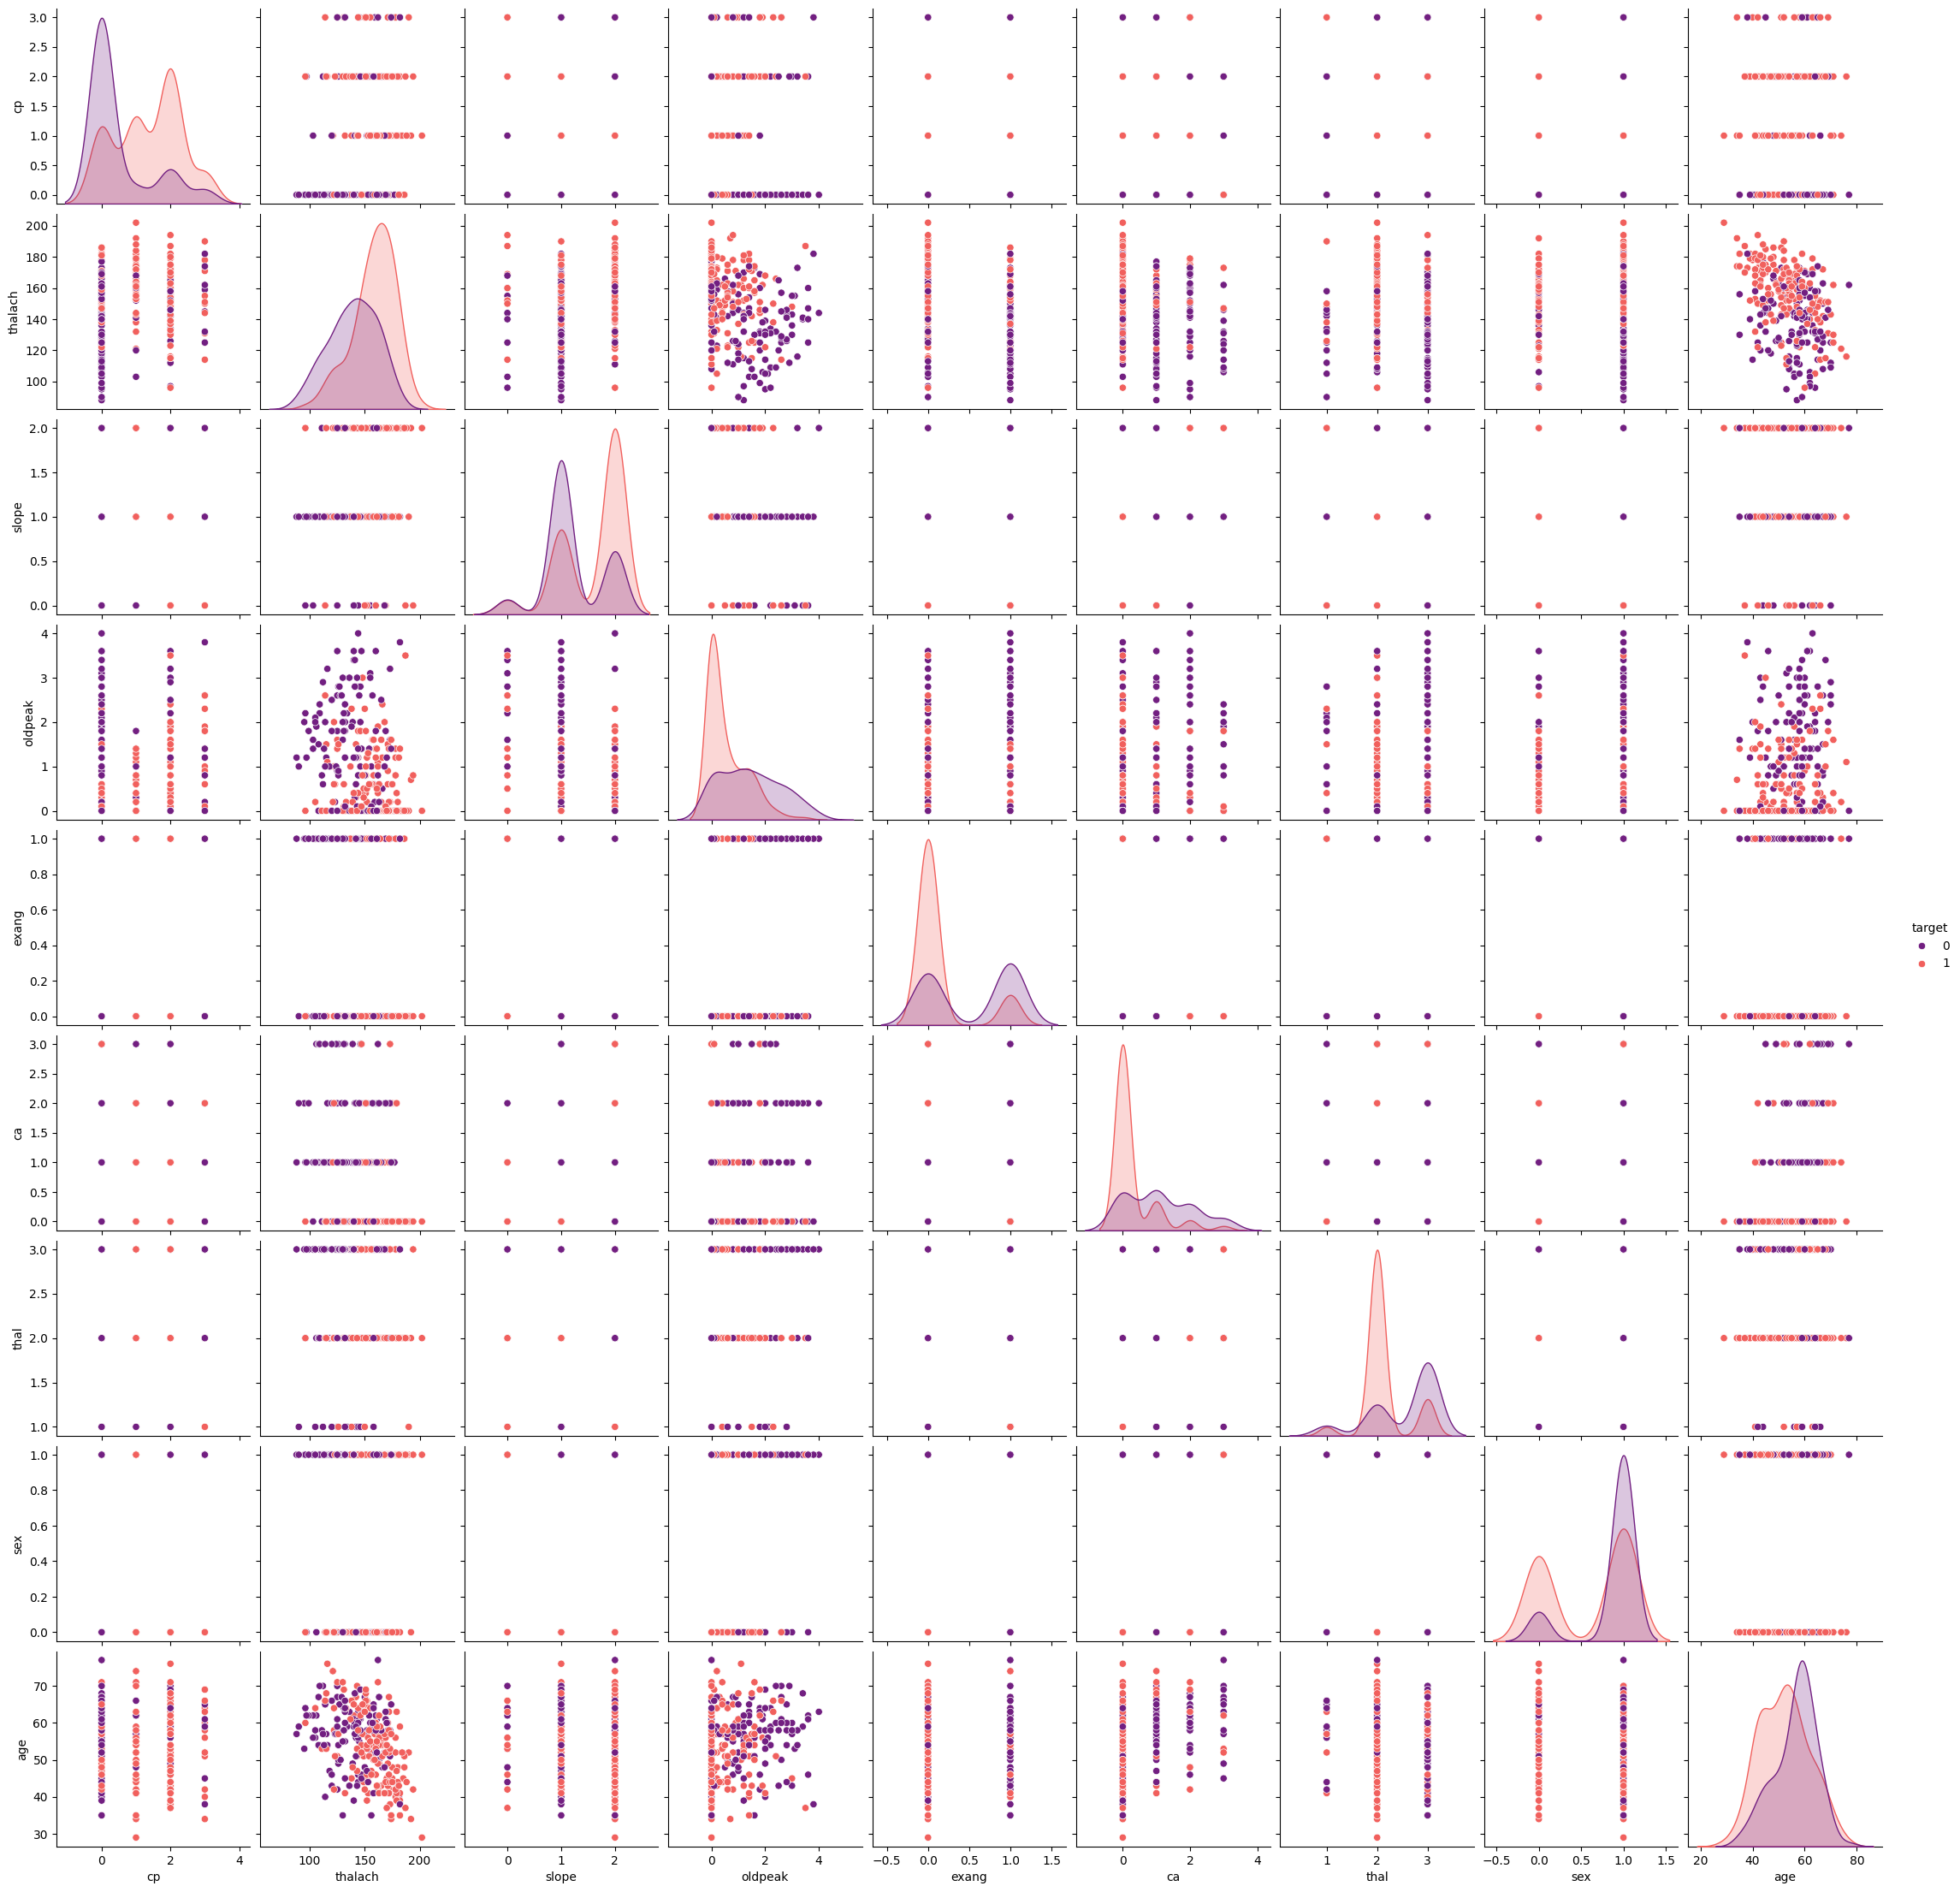

In [ ]:
var_pairplot=['cp', 'thalach', 'slope', 'oldpeak', 'exang', 'ca', 'thal', 'sex', 'age','target']#add 'target' feature to compare with other feature
df_pairplot=df[var_pairplot]
sns.pairplot(df_pairplot, hue='target', palette='magma')
plt.show()

# Modelling

In [ ]:
modelling_variable = ['cp', 'thalach', 'slope', 'oldpeak', 'exang', 'ca', 'thal', 'sex', 'age','target']
df = df[modelling_variable]
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 283 entries, 0 to 878
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cp       283 non-null    int64  
 1   thalach  283 non-null    int64  
 2   slope    283 non-null    int64  
 3   oldpeak  283 non-null    float64
 4   exang    283 non-null    int64  
 5   ca       283 non-null    int64  
 6   thal     283 non-null    int64  
 7   sex      283 non-null    int64  
 8   age      283 non-null    int64  
 9   target   283 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 24.3 KB


In [ ]:
# Pengecekan karakter dari data kategorikal
for i in modelling_variable:
    print("Berikut ini merupakan informasi: {} dengan {}".format(i, data[i].unique()))
    print()

Berikut ini merupakan informasi: cp dengan ['typical angina' 'atypical angina' 'non-anginal pain' 'asymtomatic']

Berikut ini merupakan informasi: thalach dengan [168 155 125 161 106 122 145 144 116 136 192 156 142 109 162 165 148 172
 173 146 179 152 115 112 163 147 182 105 150 151 169 166 178 132 160 123
 139 180 164 202 157 159 170 140 138 175 158 126 141 167  95 190 118 103
 181 108 177 111 143 134 120 171 149 153  88 174 114  96 124 131 185 194
 128 127 186 184 154 188 130 133 137  99 121 187  97  90 129 113]

Berikut ini merupakan informasi: slope dengan ['upsloping' 'downsloping' 'flat']

Berikut ini merupakan informasi: oldpeak dengan [1.  3.1 2.6 0.  1.9 0.8 3.2 1.6 3.  0.7 1.5 2.2 1.1 0.3 0.4 0.6 2.8 1.2
 2.9 3.6 1.4 0.2 2.  0.9 1.8 3.4 4.  2.5 0.5 0.1 2.1 2.4 3.8 2.3 1.3 3.5]

Berikut ini merupakan informasi: exang dengan ['No' 'Yes']

Berikut ini merupakan informasi: ca dengan ['Number of major vessels: 2' 'Number of major vessels: 0'
 'Number of major vessels: 1' 'Number o

In [ ]:
# Melihat tipe data
df.dtypes

,0
cp,int64
thalach,int64
slope,int64
oldpeak,float64
exang,int64
ca,int64
thal,int64
sex,int64
age,int64
target,int64


**Independent and Dependent Variable**

In [ ]:
# Define X and y
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
# Melihat kolom yang termasuk variable indepnden
X.head()

,cp,thalach,slope,oldpeak,exang,ca,thal,sex,age
0,0,168,2,1.0,0,2,3,1,52
1,0,155,0,3.1,1,0,3,1,53
2,0,125,0,2.6,1,0,3,1,70
3,0,161,2,0.0,0,1,3,1,61
4,0,106,1,1.9,0,3,2,0,62


In [ ]:
# Melihat variabel dependen
y.head()

,target
0,0
1,0
2,0
3,0
4,0


**Data Scalling**

In [ ]:
# Mendefinisikan standard scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Splitting Data**

In [ ]:
# Mendefinisikan pemisahan data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=100)

# Menampilkan hasil pemisahan berdasarkan kolom dan baris
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226, 9)
(57, 9)
(226,)
(57,)


**Modelling**

In [ ]:
# Menyiapkan libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
# Logistic Regression

clf = LogisticRegression()
# train the classifier
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
# printing the test accuracy
print("The test accuracy score of Logistic Regression Classifier is ", accuracy_score(y_test, y_pred))

The test accuracy score of Logistic Regression Classifier is  0.8070175438596491


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.83      0.78        23
           1       0.87      0.79      0.83        34

    accuracy                           0.81        57
   macro avg       0.80      0.81      0.80        57
weighted avg       0.81      0.81      0.81        57



In [ ]:
# Decision Tree

clf = DecisionTreeClassifier()
# train the classifier
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
# printing the test accuracy
print("The test accuracy score of Decision Tree Classifier is ", accuracy_score(y_test, y_pred))

The test accuracy score of Decision Tree Classifier is  0.7368421052631579


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.74      0.69        23
           1       0.81      0.74      0.77        34

    accuracy                           0.74        57
   macro avg       0.73      0.74      0.73        57
weighted avg       0.74      0.74      0.74        57



In [ ]:
# Random Forest

clf = RandomForestClassifier()
# train the classifier
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
# printing the test accuracy
print("The test accuracy score of Random Forest Classifier is ", accuracy_score(y_test, y_pred))

The test accuracy score of Random Forest Classifier is  0.8245614035087719


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.74      0.77        23
           1       0.83      0.88      0.86        34

    accuracy                           0.82        57
   macro avg       0.82      0.81      0.81        57
weighted avg       0.82      0.82      0.82        57



In [ ]:
# MLP Classifier

clf = MLPClassifier()
# train the classifier
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
# printing the test accuracy
print("The test accuracy score of MLP Classifier is ", accuracy_score(y_test, y_pred))

The test accuracy score of MLP Classifier is  0.7894736842105263


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.83      0.76        23
           1       0.87      0.76      0.81        34

    accuracy                           0.79        57
   macro avg       0.79      0.80      0.79        57
weighted avg       0.80      0.79      0.79        57



# Evaluation (Hyperparameter Tuning)

**Logistic Regretion**

In [ ]:
# Logistic regression classifier with hyperparameter
clf = LogisticRegression()

param_grid = {
    'max_iter': [100, 200, 300],
    'multi_class': ['auto', 'ovr', 'multinomial'],
    'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

gs1 = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        scoring='roc_auc'
    )

fit_clf_lg = gs1.fit(X_train, y_train)

print("Best Hyperparameters: ", fit_clf_lg.best_params_)
print("Best Score: ", fit_clf_lg.best_score_)

Best Hyperparameters:  {'max_iter': 100, 'multi_class': 'multinomial', 'solver': 'newton-cg'}
Best Score:  0.9109936507936508


In [ ]:
y_pred = fit_clf_lg.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.83      0.78        23
           1       0.87      0.79      0.83        34

    accuracy                           0.81        57
   macro avg       0.80      0.81      0.80        57
weighted avg       0.81      0.81      0.81        57



**Decision Tree**

In [ ]:
# Decision Tree classifier with hyperparameter
clf = DecisionTreeClassifier()

param_grid = {
    'min_samples_leaf': [1, 2, 5, 10],
    'max_depth': [None, 10, 20, 30],
    'criterion': ['gini', 'entropy']
}

gs1 = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        scoring='roc_auc'
    )

fit_clf_dt = gs1.fit(X_train, y_train)

print("Best Hyperparameters: ", fit_clf_dt.best_params_)
print("Best Score: ", fit_clf_dt.best_score_)

Best Hyperparameters:  {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 10}
Best Score:  0.8548809523809524


In [ ]:
y_pred = fit_clf_dt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.65      0.70        23
           1       0.78      0.85      0.82        34

    accuracy                           0.77        57
   macro avg       0.77      0.75      0.76        57
weighted avg       0.77      0.77      0.77        57



**Random Forest**

In [ ]:
# Random Forest classifier with hyperparameter
clf = RandomForestClassifier()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'criterion': ['gini', 'entropy']
}

gs1 = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        scoring='roc_auc'
    )

fit_clf_rf = gs1.fit(X_train, y_train)

print("Best Hyperparameters: ", fit_clf_rf.best_params_)
print("Best Score: ", fit_clf_rf.best_score_)

Best Hyperparameters:  {'criterion': 'gini', 'max_depth': 30, 'n_estimators': 200}
Best Score:  0.9111428571428573


In [ ]:
y_pred = fit_clf_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        23
           1       0.88      0.88      0.88        34

    accuracy                           0.86        57
   macro avg       0.85      0.85      0.85        57
weighted avg       0.86      0.86      0.86        57



**MLP**

In [ ]:
# MLP Classifier with hyperparameter
clf = MLPClassifier()

param_grid = {
    'hidden_layer_sizes': [(50,50,50), (50,100,50), (100,)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam']
}

gs1 = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        scoring='roc_auc'
    )

fit_clf_mlp = gs1.fit(X_train, y_train)

print("Best Hyperparameters: ", fit_clf_mlp.best_params_)
print("Best Score: ", fit_clf_mlp.best_score_)

Best Hyperparameters:  {'activation': 'tanh', 'hidden_layer_sizes': (50, 50, 50), 'solver': 'adam'}
Best Score:  0.9212888888888889


In [ ]:
y_pred = fit_clf_mlp.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.91      0.79        23
           1       0.93      0.74      0.82        34

    accuracy                           0.81        57
   macro avg       0.81      0.82      0.81        57
weighted avg       0.83      0.81      0.81        57



**ROC Analysis**

In [ ]:
# ROC analysis untuk masing-masing model
# Predict the probabilities for the positive class
y_pred_logreg = fit_clf_lg.predict_proba(X_test)[:, 1]
y_pred_rf = fit_clf_rf.predict_proba(X_test)[:, 1]
y_pred_dt = fit_clf_dt.predict_proba(X_test)[:, 1]
y_pred_mlp = fit_clf_mlp.predict_proba(X_test)[:, 1]

# Calculate the AUC-ROC scores
auc_logreg = roc_auc_score(y_test, y_pred_logreg)
auc_rf = roc_auc_score(y_test, y_pred_rf)
auc_dt = roc_auc_score(y_test, y_pred_dt)
auc_mlp = roc_auc_score(y_test, y_pred_mlp)

print(f"AUC-ROC for Logistic Regression: {auc_logreg}")
print(f"AUC-ROC for Random Forest: {auc_rf}")
print(f"AUC-ROC for Decision Tree: {auc_dt}")
print(f"AUC-ROC for MLP: {auc_mlp}")

AUC-ROC for Logistic Regression: 0.8849104859335037
AUC-ROC for Random Forest: 0.8906649616368286
AUC-ROC for Decision Tree: 0.7851662404092071
AUC-ROC for MLP: 0.870843989769821


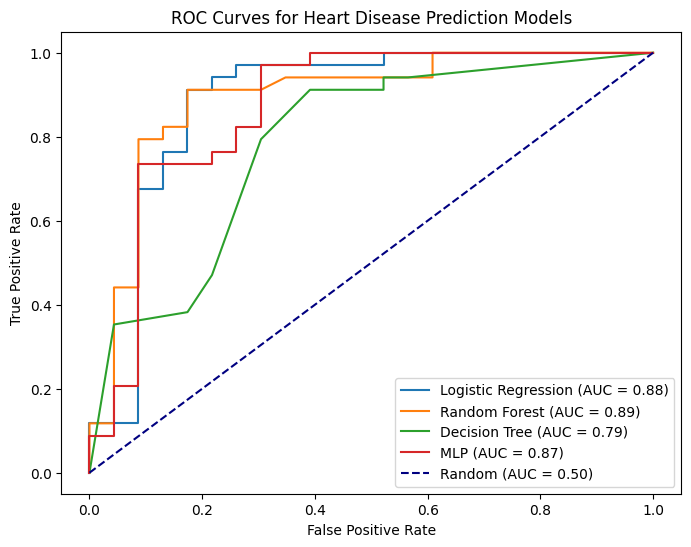

In [ ]:
# Grafik untuk ROC Analysis
#Membuat ROC Analisis
def plot_roc_curves(y_test, y_pred_logreg, y_pred_rf, y_pred_dt, y_pred_mlp):
    plt.figure(figsize=(8, 6))

    # Calculate ROC curves for each model
    fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_logreg)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
    fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt)
    fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp)

    # Plot ROC curves
    plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.2f})')
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
    plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
    plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc_mlp:.2f})')

    # Plot random classifier
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random (AUC = 0.50)')

    # Format the plot
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Heart Disease Prediction Models')
    plt.legend()
    plt.show()

plot_roc_curves(y_test, y_pred_logreg, y_pred_rf, y_pred_dt, y_pred_mlp)

In [ ]:
# Menentukan Thresholds dengan ROC analysis
def find_rates_for_thresholds(y_test, y_pred, thresholds):
    fpr_list = []
    tpr_list = []
    for threshold in thresholds:
        y_pred_binary = (y_pred > threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
        fpr = fp / (fp + tn)
        tpr = tp / (tp + fn)
        fpr_list.append(fpr)
        tpr_list.append(tpr)
    return fpr_list, tpr_list

thresholds = np.arange(0, 1.1, 0.1)

fpr_logreg, tpr_logreg = find_rates_for_thresholds(y_test, y_pred_logreg, thresholds)
fpr_rf, tpr_rf = find_rates_for_thresholds(y_test, y_pred_rf, thresholds)
fpr_dt, tpr_dt = find_rates_for_thresholds(y_test, y_pred_dt, thresholds)
fpr_mlp, tpr_mlp = find_rates_for_thresholds(y_test, y_pred_mlp, thresholds)

'''TODO: Silahkan buat Summary DataFrame'''
summary_df = pd.DataFrame({
    'Threshold': thresholds,
    'Logistic Regression FPR': fpr_logreg,
    'Logistic Regression TPR': tpr_logreg,
    'Random Forest FPR': fpr_rf,
    'Random Forest TPR': tpr_rf,
    'Decision Tree FPR': fpr_dt,
    'Decision Tree TPR': tpr_dt,
    'MLP FPR': fpr_mlp,
    'MLP TPR': tpr_mlp
})

print(summary_df)

    Threshold  Logistic Regression FPR  Logistic Regression TPR  \
0         0.0                 1.000000                 1.000000   
1         0.1                 0.478261                 0.970588   
2         0.2                 0.347826                 0.970588   
3         0.3                 0.217391                 0.941176   
4         0.4                 0.173913                 0.794118   
5         0.5                 0.173913                 0.794118   
6         0.6                 0.130435                 0.764706   
7         0.7                 0.130435                 0.676471   
8         0.8                 0.086957                 0.647059   
9         0.9                 0.086957                 0.411765   
10        1.0                 0.000000                 0.000000   

    Random Forest FPR  Random Forest TPR  Decision Tree FPR  \
0            0.826087           1.000000           0.565217   
1            0.608696           1.000000           0.521739   
2     

In [ ]:
# Menentukan best threshold untuk masing-masing threshold
def find_best_threshold(y_test, y_pred):
    # based on Youden's Index
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

best_threshold_logreg = find_best_threshold(y_test, y_pred_logreg)
best_threshold_rf = find_best_threshold(y_test, y_pred_rf)
best_threshold_dt = find_best_threshold(y_test, y_pred_dt)
best_threshold_mlp = find_best_threshold(y_test, y_pred_mlp)

print(f"Best threshold for Logistic Regression: {best_threshold_logreg}")
print(f"Best threshold for Random Forest: {best_threshold_rf}")
print(f"Best threshold for Decision Tree: {best_threshold_dt}")
print(f"Best threshold for MLP: {best_threshold_mlp}")

Best threshold for Logistic Regression: 0.3333137961556302
Best threshold for Random Forest: 0.475
Best threshold for Decision Tree: 0.36363636363636365
Best threshold for MLP: 0.0637572065233258


**Save the best model**

In [ ]:
# Menyimpan model yang terbaik
import pickle
# Menyimpan model terbaik dengan pickle
pklname = "best_classifier.pkl"

with open(pklname, 'wb') as file:
    pickle.dump(fit_clf_rf, file)